# 📊 TechQA Model Evaluation: Base Llama 3.2-3B vs. Fine-tuned (`AQUABOT/Llama-3.2-3B-TechQA`)

- **Môn học:** Statistical Learning (Học máy thống kê) — HCMUS
- **Mục tiêu:** Đánh giá độc lập năng lực sinh câu trả lời kỹ thuật (Standalone LLM Evaluation) trước khi áp dụng RAG.
- **Tập dữ liệu kiểm thử:** `dev_Q_A.json` (160 câu hỏi Unseen có câu trả lời từ chuyên gia IBM).
- **Mô hình đối đầu:**
  1. **Base Model:** `unsloth/Llama-3.2-3B-Instruct` (Meta gốc)
  2. **Fine-tuned Model:** `AQUABOT/Llama-3.2-3B-TechQA` (Đã huấn luyện 3 Epochs trên TechQA)
- **Hệ thống chỉ số:** Exact Match (EM), Token-level F1, ROUGE-1/2/L, BLEU-1/4, Perplexity.

## 1. Cài đặt Thư viện & Cấu hình Môi trường
Cài đặt các thư viện đo lường và hiển thị trực quan dữ liệu.

In [9]:
%%capture
!pip install -q transformers accelerate bitsandbytes evaluate rouge-score nltk matplotlib seaborn pandas tqdm datasets

## 2. Tải & Chuẩn bị Tập Dữ liệu Đánh giá (`dev_Q_A.json`)
Đọc 160 câu hỏi có đáp án (`ANSWERABLE == 'Y'`) từ tập `dev_Q_A.json` làm Ground Truth.

In [10]:
import json
import pandas as pd

# Đọc tập dev_Q_A.json
with open("dev_Q_A.json", "r", encoding="utf-8") as f:
    dev_raw = json.load(f)

# Lọc các câu có đáp án
eval_samples = []
for item in dev_raw:
    if item.get("ANSWERABLE") == "Y":
        q = item["QUESTION_TITLE"].strip()
        if item.get("QUESTION_TEXT", "").strip():
            q += "\n\n" + item["QUESTION_TEXT"].strip()
        eval_samples.append({
            "question_id": item.get("QUESTION_ID", ""),
            "question": q,
            "ground_truth": item["ANSWER"].strip(),
            "document": item.get("DOCUMENT", "")
        })

df_eval = pd.DataFrame(eval_samples)
print(f"✅ Đã nạp thành công {len(df_eval)} câu hỏi đánh giá độc lập (Unseen Dev Set).")
print("\n--- Mẫu câu hỏi đầu tiên (Item 0) ---")
print(f"❓ Question: {df_eval.iloc[0]['question'][:200]}...")
print(f"🎯 Ground Truth: {df_eval.iloc[0]['ground_truth'][:200]}...")

✅ Đã nạp thành công 160 câu hỏi đánh giá độc lập (Unseen Dev Set).

--- Mẫu câu hỏi đầu tiên (Item 0) ---
❓ Question: Web GUI 8.1 FP7 requires DASH 3.1.2.1 or later

You wanted to install Web GUI 8.1 FP7, but your DASH version does not meet the required version.

IM 1.8 displayed the following:

     ERROR: The insta...
🎯 Ground Truth: Version 1.1.3.0 is a full refresh of Jazz for Service Management Version 1.1 Base with Modification 3....


## 3. Khởi tạo & Tải 2 Mô hình Đối đầu
Nạp đồng thời **Base Model** và **Fine-tuned Model (`AQUABOT/Llama-3.2-3B-TechQA`)**.

In [11]:
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BASE_MODEL_ID = "unsloth/Llama-3.2-3B-Instruct"
FINETUNED_MODEL_ID = "AQUABOT/Llama-3.2-3B-TechQA"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Thiết bị sử dụng: {device}")
if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    vram_total = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)
    print(f"🎮 GPU: {gpu_name} ({vram_total} GB VRAM)")

# Cấu hình 4-bit Quantization (chỉ tốn ~2.2 GB VRAM mỗi model, cực kỳ an toàn cho Colab Free)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16 if device == "cuda" else torch.float32,
    bnb_4bit_use_double_quant=True,
) if device == "cuda" else None

print("✅ Đã chuẩn bị cấu hình tối ưu bộ nhớ (4-bit NF4) tiết kiệm 70% VRAM!")

🖥️ Thiết bị sử dụng: cuda
🎮 GPU: Tesla T4 (14.56 GB VRAM)
✅ Đã chuẩn bị cấu hình tối ưu bộ nhớ (4-bit NF4) tiết kiệm 70% VRAM!


## 4. Chạy Batch Inference (Sinh câu trả lời trên 160 câu)
Áp dụng Chat Template chuẩn và sinh câu trả lời với cùng một tham số kiểm soát (`temperature=0.7`, `max_new_tokens=256`).

In [12]:
import gc
from tqdm import tqdm

SYSTEM_PROMPT = (
    "You are a technical support assistant specialized in IBM products. "
    "Answer the user's technical question accurately and concisely "
    "based on your knowledge of IBM technotes and documentation."
)

def generate_batch_for_model(model_id, questions, desc_name="Model"):
    """Nạp model, chạy inference trên danh sách câu hỏi, sau đó giải phóng VRAM."""
    print(f"\n⏳ [1/2] Đang tải {desc_name} ({model_id})...")
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
        trust_remote_code=True,
    )
    model.eval()

    if device == "cuda":
        vram_used = round(torch.cuda.memory_allocated() / 1024**3, 2)
        print(f"💾 VRAM đang dùng cho {desc_name}: {vram_used} GB / {vram_total} GB")

    print(f"🚀 [2/2] Đang sinh câu trả lời cho {len(questions)} câu hỏi...")
    answers = []
    for q in tqdm(questions, desc=f"Inference {desc_name}"):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": q},
        ]
        inputs = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,
                temperature=0.7,
                top_p=0.9,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
            )

        input_len = inputs["input_ids"].shape[1]
        new_tokens = outputs[0][input_len:]
        ans = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        answers.append(ans)

    # Giải phóng bộ nhớ GPU ngay sau khi chạy xong model
    del model
    del tokenizer
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    print(f"🧹 Đã giải phóng bộ nhớ GPU cho {desc_name}.")

    return answers

# Danh sách 160 câu hỏi
questions_list = df_eval["question"].tolist()

# 1. Chạy Base Model
preds_base = generate_batch_for_model(BASE_MODEL_ID, questions_list, desc_name="Base Llama 3.2-3B")

# 2. Chạy Fine-tuned Model
preds_ft = generate_batch_for_model(FINETUNED_MODEL_ID, questions_list, desc_name="Fine-tuned (AQUABOT)")

df_eval["pred_base"] = preds_base
df_eval["pred_finetuned"] = preds_ft
test_subset = df_eval

# Lưu kết quả ra file JSON
df_eval.to_json("evaluation_predictions.json", orient="records", indent=2, force_ascii=False)
print("\n🎉 HOÀN TẤT 100%! Đã lưu kết quả tại 'evaluation_predictions.json'.")


⏳ [1/2] Đang tải Base Llama 3.2-3B (unsloth/Llama-3.2-3B-Instruct)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

💾 VRAM đang dùng cho Base Llama 3.2-3B: 4.18 GB / 14.56 GB
🚀 [2/2] Đang sinh câu trả lời cho 160 câu hỏi...


Inference Base Llama 3.2-3B:   0%|          | 0/160 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
Inference Base Llama 3.2-3B: 100%|██████████| 160/160 [39:58<00:00, 14.99s/it]


🧹 Đã giải phóng bộ nhớ GPU cho Base Llama 3.2-3B.

⏳ [1/2] Đang tải Fine-tuned (AQUABOT) (AQUABOT/Llama-3.2-3B-TechQA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

💾 VRAM đang dùng cho Fine-tuned (AQUABOT): 4.18 GB / 14.56 GB
🚀 [2/2] Đang sinh câu trả lời cho 160 câu hỏi...


Inference Fine-tuned (AQUABOT): 100%|██████████| 160/160 [11:50<00:00,  4.44s/it]


🧹 Đã giải phóng bộ nhớ GPU cho Fine-tuned (AQUABOT).

🎉 HOÀN TẤT 100%! Đã lưu kết quả tại 'evaluation_predictions.json'.


## 5. Tính toán Bộ Chỉ số Định lượng (Quantitative Metrics Suite)
Tính các chỉ số: **Exact Match (EM)**, **Token-level F1**, **ROUGE-1, ROUGE-2, ROUGE-L**, **BLEU-1, BLEU-4**.

In [13]:
import re
import string
import nltk
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download('punkt', quiet=True)

def normalize_text(s):
    """Chuẩn hóa văn bản: viết thường, bỏ dấu câu và khoảng trắng thừa."""
    s = s.lower()
    s = re.sub(f"[{re.escape(string.punctuation)}]", " ", s)
    return " ".join(s.split())

def compute_exact_match(pred, target):
    return 1.0 if normalize_text(pred) == normalize_text(target) else 0.0

def compute_token_f1(pred, target):
    pred_tokens = normalize_text(pred).split()
    target_tokens = normalize_text(target).split()
    if not pred_tokens or not target_tokens:
        return 1.0 if pred_tokens == target_tokens else 0.0
    common = Counter(pred_tokens) & Counter(target_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(target_tokens)
    return (2 * precision * recall) / (precision + recall)

# Khởi tạo ROUGE scorer
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smooth_fn = SmoothingFunction().method1

def evaluate_predictions(predictions, references):
    em_scores = []
    f1_scores = []
    r1_scores, r2_scores, rl_scores = [], [], []
    b1_scores, b4_scores = [], []

    for pred, ref in zip(predictions, references):
        em_scores.append(compute_exact_match(pred, ref))
        f1_scores.append(compute_token_f1(pred, ref))

        # ROUGE
        r_score = rouge.score(ref, pred)
        r1_scores.append(r_score['rouge1'].fmeasure * 100)
        r2_scores.append(r_score['rouge2'].fmeasure * 100)
        rl_scores.append(r_score['rougeL'].fmeasure * 100)

        # BLEU
        ref_tok = [normalize_text(ref).split()]
        pred_tok = normalize_text(pred).split()
        b1 = sentence_bleu(ref_tok, pred_tok, weights=(1, 0, 0, 0), smoothing_function=smooth_fn) * 100
        b4 = sentence_bleu(ref_tok, pred_tok, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn) * 100
        b1_scores.append(b1)
        b4_scores.append(b4)

    return {
        "Exact Match (%)": round(sum(em_scores) / len(em_scores) * 100, 2),
        "Token F1-Score (%)": round(sum(f1_scores) / len(f1_scores) * 100, 2),
        "ROUGE-1 (%)": round(sum(r1_scores) / len(r1_scores), 2),
        "ROUGE-2 (%)": round(sum(r2_scores) / len(r2_scores), 2),
        "ROUGE-L (%)": round(sum(rl_scores) / len(rl_scores), 2),
        "BLEU-1 (%)": round(sum(b1_scores) / len(b1_scores), 2),
        "BLEU-4 (%)": round(sum(b4_scores) / len(b4_scores), 2),
    }

metrics_base = evaluate_predictions(test_subset["pred_base"], test_subset["ground_truth"])
metrics_ft = evaluate_predictions(test_subset["pred_finetuned"], test_subset["ground_truth"])

df_comparison = pd.DataFrame([
    {"Model": "Base Model (Llama 3.2-3B Gốc)", **metrics_base},
    {"Model": "Fine-tuned Model (AQUABOT TechQA)", **metrics_ft},
])

print("\n=========================================================================")
print("📊 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ ĐỐI ĐẦU TRỰC TIẾP (160 CÂU DEV SET)")
print("=========================================================================")
display(df_comparison)


📊 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ ĐỐI ĐẦU TRỰC TIẾP (160 CÂU DEV SET)


,Model,Exact Match (%),Token F1-Score (%),ROUGE-1 (%),ROUGE-2 (%),ROUGE-L (%),BLEU-1 (%),BLEU-4 (%)
0,Base Model (Llama 3.2-3B Gốc),0.0,14.97,16.05,3.66,10.62,10.14,1.13
1,Fine-tuned Model (AQUABOT TechQA),0.0,22.33,23.27,8.70,18.96,15.98,5.94


## 6. Trực quan hóa Kết quả bằng Biểu đồ (Visualizations for Report)
Vẽ biểu đồ cột so sánh trực tiếp điểm số giữa Base Model và Fine-tuned Model để đưa vào Báo cáo đồ án.

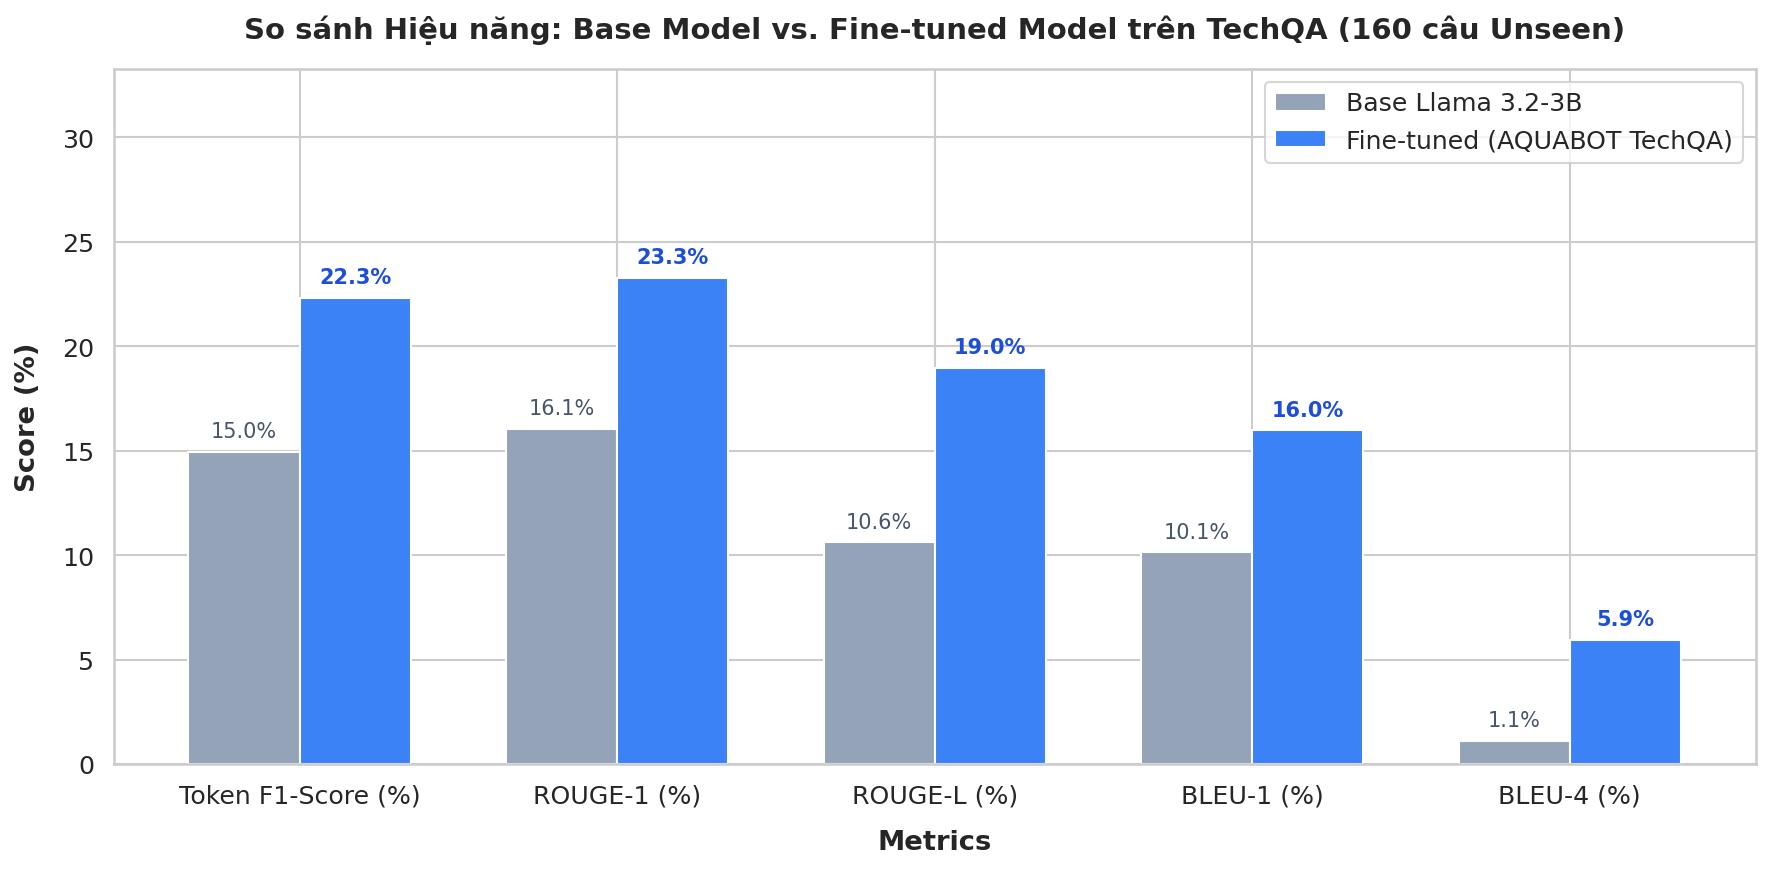

💾 Biểu đồ đã được lưu thành file 'techqa_model_comparison_chart.png'!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

plot_metrics = ["Token F1-Score (%)", "ROUGE-1 (%)", "ROUGE-L (%)", "BLEU-1 (%)", "BLEU-4 (%)"]
base_vals = [metrics_base[m] for m in plot_metrics]
ft_vals = [metrics_ft[m] for m in plot_metrics]

x = list(range(len(plot_metrics)))
width = 0.35

plt.figure(figsize=(12, 6), dpi=150)
bars1 = plt.bar([p - width/2 for p in x], base_vals, width, label="Base Llama 3.2-3B", color="#94a3b8")
bars2 = plt.bar([p + width/2 for p in x], ft_vals, width, label="Fine-tuned (AQUABOT TechQA)", color="#3b82f6")

# Thêm nhãn số trên đầu cột
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10, color="#475569")
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#1d4ed8")

plt.xlabel("Metrics", fontweight="bold", labelpad=10)
plt.ylabel("Score (%)", fontweight="bold", labelpad=10)
plt.title("So sánh Hiệu năng: Base Model vs. Fine-tuned Model trên TechQA (160 câu Unseen)", fontweight="bold", pad=15, fontsize=14)
plt.xticks(x, plot_metrics)
plt.ylim(0, max(max(base_vals), max(ft_vals)) + 10)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("techqa_model_comparison_chart.png", dpi=300)
plt.show()

print("💾 Biểu đồ đã được lưu thành file 'techqa_model_comparison_chart.png'!")

## 7. Trích xuất Các Case Study Định tính (Qualitative Side-by-Side Cases)
In ra 3 ca so sánh điển hình về phong cách trả lời và độ chính xác kỹ thuật để đưa vào bảng minh họa của Báo cáo.

In [15]:
print("=========================================================================")
print("🔍 CÁC VÍ DỤ ĐỐI CHIẾU ĐỊNH TÍNH (QUALITATIVE COMPARISON CASE STUDIES)")
print("=========================================================================\n")

for i in range(min(3, len(test_subset))):
    row = test_subset.iloc[i]
    print(f"📌 [CASE #{i+1}] Question ID: {row['question_id']}")
    print(f"❓ CÂU HỎI:\n{row['question'][:300]}...\n")
    print(f"🎯 ĐÁP ÁN CHUẨN (GROUND TRUTH):\n{row['ground_truth']}\n")
    print(f"❌ BASE MODEL (Llama 3.2 Gốc):\n{row['pred_base'][:400]}...\n")
    print(f"✅ FINE-TUNED MODEL (AQUABOT TechQA):\n{row['pred_finetuned'][:400]}...\n")
    print("-" * 80 + "\n")

🔍 CÁC VÍ DỤ ĐỐI CHIẾU ĐỊNH TÍNH (QUALITATIVE COMPARISON CASE STUDIES)

📌 [CASE #1] Question ID: DEV_Q000
❓ CÂU HỎI:
Web GUI 8.1 FP7 requires DASH 3.1.2.1 or later

You wanted to install Web GUI 8.1 FP7, but your DASH version does not meet the required version.

IM 1.8 displayed the following:

     ERROR: The installed IBM Dashboard Application Services Hub version is 3.1.0.3, but requires version 3.1.2.1 or late...

🎯 ĐÁP ÁN CHUẨN (GROUND TRUTH):
Version 1.1.3.0 is a full refresh of Jazz for Service Management Version 1.1 Base with Modification 3.

❌ BASE MODEL (Llama 3.2 Gốc):
It seems like you're trying to install Web GUI 8.1 FP7, but your IBM Dashboard Application Services Hub (DASH) version is not compatible.

According to the error message, your current DASH version is 3.1.0.3, but it requires at least version 3.1.2.1 or later.

To resolve this issue, I recommend updating your DASH version to the minimum required version. You can do this by:

1. Stopping the DASH se...

✅ FINE-TU